In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Airbnb regression 
### Associated lectures: All material till lecture 13 

<div class="alert alert-info">

## Instructions
rubric={points}

You will earn points for following these instructions and successfully submitting your work in PrairieLearn.

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.

- The maximum group size is 2.
- Use group work as an opportunity to collaborate and learn new things from each other.
- Be respectful to each other and make sure you understand all the concepts in the assignment well.
- It is your responsibility to make sure your PrairieLearn group is set up correctly and that the assignment is submitted before the deadline.

### General submission instructions

- Please read the [Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2026S1/syllabus#use-of-generative-ai-in-the-course) before starting the homework assignment.
- **Run all cells before submitting:** Go to `Kernel -> Restart Kernel and Clear All Outputs`, then select `Run -> Run All Cells`. This ensures your notebook runs cleanly from start to finish without errors.
- **Save your work in JupyterLab:** Make sure `hw5.ipynb` is saved.
- **Choose one HW5 option:** HW5 has two dataset options in PrairieLearn. You are currently in the Airbnb regression option. Open and submit exactly one notebook, and do not submit both.
- **Check your saved submission in PrairieLearn:** Return to the PrairieLearn question page and click **Save only** to capture your notebook and review the preview. When you are ready to submit for grading, click **Save & Grade**.
- **Follow course submission guidelines:** Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2026S1/docs/homework-instructions/) for detailed guidance on completing and submitting assignments.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
 




<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

This version of Homework 5 uses the [New York City Airbnb Open Data dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data). You will work on a regression problem where the goal is to predict `reviews_per_month`, as a proxy for listing popularity. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts in creating more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features we are using are in `listings.csv.gz` for the New York City dataset. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.

<div class="alert alert-info">
    
**Your tasks:**

1. Spend some time understanding the problem and what each feature means. You can find an explanation of the features [here](https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit).
2. Download the dataset and load it into a pandas DataFrame.
3. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>


<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

This dataset provides 453 records of Airbnb listings, covering 85 features such as price, property type, number of bedrooms, location etc... Many of which are directly related to reviews_per_month. Therefore, the dataset provides a solid foundation for our prediction task. However, we still need to process the dataset, including removing some irrelevant features, these include URLs, IDs, and certain categories that contain no useful information. Overall, the dataset is of moderate size with a reasonable number of features, making it a suitable starting point for basic predictive modelling.


In [3]:
import pandas as pd

df = pd.read_csv("listings.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20260215064701,2026-02-15,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06
1,3820211,https://www.airbnb.com/rooms/3820211,20260215064701,2026-02-15,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,NaN,7,7,0,0,2.26
2,5651579,https://www.airbnb.com/rooms/5651579,20260215064701,2026-02-15,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.86,4.76,4.63,NaN,NaN,2,1,1,0,2.96
3,6015313,https://www.airbnb.com/rooms/6015313,20260215064701,2026-02-15,city scrape,Comfortable 3BR Home w/ Central Air | Pine Hills,Updated 3-bedroom home in Pine Hills near hosp...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,31223807,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
4,6623339,https://www.airbnb.com/rooms/6623339,20260215064701,2026-02-15,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,NaN,7,7,0,0,2.55


In [4]:
df.shape

(453, 85)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [5]:
train_df, test_df = train_test_split(
    df, test_size=0.3, random_state=123 #choose 123 as our random_state
)  
X_train, y_train = train_df.drop(columns=["reviews_per_month"]), train_df["reviews_per_month"]
X_test, y_test = test_df.drop(columns=["reviews_per_month"]), test_df["reviews_per_month"]
train_df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
451,1607340037754690734,https://www.airbnb.com/rooms/1607340037754690734,20260215064701,2026-02-15,city scrape,Cozy 1BD Room in Albany with Breakfast,Enjoy a comfortable Stay in this cozy Albany h...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,466790114,...,NaN,NaN,NaN,NaN,NaN,30,29,1,0,NaN
159,813640070361665090,https://www.airbnb.com/rooms/813640070361665090,20260215064701,2026-02-15,city scrape,The front room w/ TV and king size bed,"Place is within 2-3 miles of AMC, St. Peter's,...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,116935236,...,4.80,4.85,4.80,NaN,NaN,5,0,5,0,0.65
200,942750363293463100,https://www.airbnb.com/rooms/942750363293463100,20260215064701,2026-02-15,city scrape,The spacious room w/ tv dresser/desk,"Place is within 2-3 miles of AMC, St. Peter's,...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,116935236,...,4.95,4.95,4.95,NaN,NaN,5,0,5,0,0.79
404,1511463115578002586,https://www.airbnb.com/rooms/1511463115578002586,20260215064701,2026-02-15,city scrape,Large 1 bedroom downtown!,"Spacious 1BR/1BA condo in Albany, perfect for ...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,390089294,...,NaN,NaN,NaN,NaN,NaN,6,6,0,0,NaN
258,1158059552251999833,https://www.airbnb.com/rooms/1158059552251999833,20260215064701,2026-02-15,city scrape,"""The Albany Allen Home"" Private Bedroom 1",Charming first-floor apartment with five cozy ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,349460842,...,5.00,5.00,4.50,NaN,NaN,17,4,13,0,0.11


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

In [6]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 317 entries, 451 to 365
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            317 non-null    int64  
 1   listing_url                                   317 non-null    str    
 2   scrape_id                                     317 non-null    int64  
 3   last_scraped                                  317 non-null    str    
 4   source                                        317 non-null    str    
 5   name                                          317 non-null    str    
 6   description                                   310 non-null    str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   317 non-null    str    
 9   host_id                                       317 non-null    int64  
 10  host

In [7]:
train_df.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.170000e+02,3.170000e+02,0.0,3.170000e+02,3.170000e+02,0.0,317.000000,317.000000,317.000000,317.000000,...,271.000000,271.000000,271.000000,0.0,0.0,317.000000,317.000000,317.00000,317.0,271.000000
mean,9.050331e+17,2.026022e+13,NaN,2.602410e+08,1.469276e+18,NaN,6.533123,5.712934,4.091483,5.839117,...,4.838598,4.630148,4.699410,NaN,NaN,8.018927,6.018927,2.00000,0.0,1.690517
std,5.696350e+17,0.000000e+00,NaN,1.984559e+08,1.567263e+16,NaN,3.296960,3.208413,2.958760,3.452570,...,0.362938,0.420769,0.376572,NaN,NaN,8.212734,7.796032,3.97301,0.0,1.709144
min,3.820211e+06,2.026022e+13,NaN,1.017349e+06,1.462535e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,2.500000,NaN,NaN,1.000000,0.000000,0.00000,0.0,0.050000
25%,6.196951e+17,2.026022e+13,NaN,4.849002e+07,1.463574e+18,NaN,4.000000,3.000000,2.000000,3.000000,...,4.830000,4.440000,4.630000,NaN,NaN,2.000000,1.000000,0.00000,0.0,0.405000
50%,1.018972e+18,2.026022e+13,NaN,2.329679e+08,1.468114e+18,NaN,7.000000,6.000000,4.000000,6.000000,...,4.950000,4.760000,4.800000,NaN,NaN,5.000000,3.000000,0.00000,0.0,1.190000
75%,1.393635e+18,2.026022e+13,NaN,4.338843e+08,1.469695e+18,NaN,10.000000,8.000000,6.000000,9.000000,...,5.000000,4.930000,4.940000,NaN,NaN,13.000000,8.000000,1.00000,0.0,2.315000
max,1.611096e+18,2.026022e+13,NaN,7.395856e+08,1.601568e+18,NaN,14.000000,11.000000,11.000000,11.000000,...,5.000000,5.000000,5.000000,NaN,NaN,30.000000,29.000000,13.00000,0.0,10.380000


1. By using the `info`, `shape` and `describe` functions, we have gained a basic understanding of our training set, which comprises 317 samples and 84 features (Not include our target). Specifically, we have 60 numerical features and 24 string features. It is worth noting that we found that only 271 of our 317 examples had a corresponding target value for `reviews_per_month`, meaning that we actually had only 271 usable examples.

In [8]:
missing = (train_df.isna().mean().sort_values(ascending=False) * 100).to_frame("missing_%")
print(missing.head(20))

cols_all_missing = train_df.columns[train_df.isna().all()].tolist()
print("\nNumber of all NaN col: " + str(len(cols_all_missing)))
print(cols_all_missing)


                               missing_%
neighborhood_overview         100.000000
host_since                    100.000000
host_acceptance_rate          100.000000
host_response_rate            100.000000
host_response_time            100.000000
host_total_listings_count     100.000000
host_verifications            100.000000
license                       100.000000
instant_bookable              100.000000
calendar_updated              100.000000
estimated_revenue_l365d       100.000000
price                         100.000000
neighbourhood                 100.000000
host_thumbnail_url            100.000000
host_neighbourhood            100.000000
neighbourhood_group_cleansed  100.000000
host_about                     43.533123
host_location                  28.391167
review_scores_value            14.511041
reviews_per_month              14.511041

Number of all NaN col: 16
['neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'hos

2. 1. In addition, we found that a large number of feature values were missing. By calculating the missing rate for each feature using a function, we discovered that 16 feature values contained absolutely no valid information.

In [9]:
categorical_candidates = X_train.select_dtypes(include=['object']).columns.tolist()
print("Total categorical: " + str(len(categorical_candidates)))
print(categorical_candidates)
numerical_candidates = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("\nTotal numerical: " + str(len(numerical_candidates)))
print(numerical_candidates)


Total categorical: 24
['listing_url', 'last_scraped', 'source', 'name', 'description', 'picture_url', 'host_url', 'host_profile_url', 'host_name', 'host_location', 'host_about', 'host_is_superhost', 'host_picture_url', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'amenities', 'has_availability', 'calendar_last_scraped', 'first_review', 'last_review']

Total numerical: 60
['id', 'scrape_id', 'neighborhood_overview', 'host_id', 'host_profile_id', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum

/tmp/ipykernel_38664/649164549.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_candidates = X_train.select_dtypes(include=['object']).columns.tolist()


2. 1. In addition, we found that our dataset contained 24 categorical features, and 60 numerical features. Among these, we identified some features that were completely useless, such as URLs. 

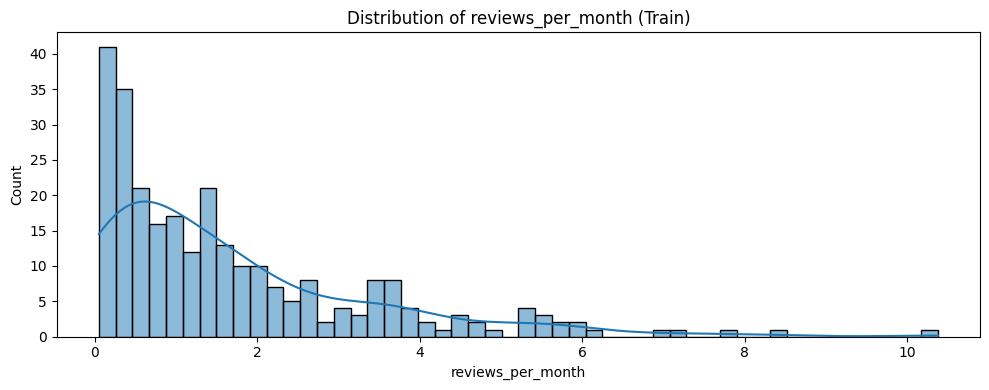

In [10]:
import seaborn as sns
plt.figure(figsize=(10,4))
sns.histplot(y_train, bins=50, kde=True)
plt.title("Distribution of reviews_per_month (Train)")

plt.tight_layout()
plt.show()

2. 2. We have created a histogram of our target values. According to this histogram, most of the data is concentrated between 0 and 2, and the entire dataset exhibits a right-skewed distribution.

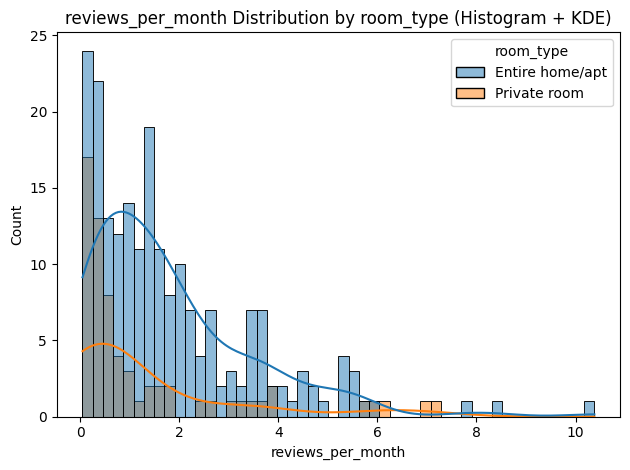

In [11]:

sns.histplot(data=train_df, x='reviews_per_month', hue='room_type', 
             bins=50, kde=True, alpha=0.5)
plt.title('reviews_per_month Distribution by room_type (Histogram + KDE)')

plt.tight_layout()
plt.show()

2. 2. We selected the room types and make a histogram of our target values. Based on this histogram, we found that both room types exhibit a distinct right-skewed distribution, and that the ‘home/apt’ type has a higher count for ‘reviews_per_month’ than the ‘private room’ type; this may be due to an imbalance between the two types in the dataset.

3. Based on our EDA analysis, I have identified the following three key observations regarding this dataset. Firstly, the training set contains 317 samples and 84 features, but 16 of these features are entirely empty and must be removed prior to modelling. Secondly, the target variable `reviews_per_month` exhibits a severely right-skewed distribution, which may adversely affect our linear model. Thirdly, the dataset contains a total of 24 categorical features, such as `room_type` and `neighbourhood_cleansed`, as well as a large number of unrelated identifiers and URLs, all of which require cleaning and encoding.

3. We have selected MAE, rmse, and R² as the primary evaluation metrics for this regression task. MAE is intuitive, as it measures the numerical value of the average prediction error in the number of monthly reviews, which facilitates the interpretation of results. Rmse and R² provides a relative benchmark for assessing how well the model performs compared to a simple baseline that always predicts the mean, helping to evaluate whether the features have indeed added predictive value.



<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

In [12]:
not_null_idx = y_train.notna()
X_train = X_train[not_null_idx].copy()
y_train = y_train[not_null_idx].copy()
not_null_idx = y_test.notna()
X_test = X_test[not_null_idx].copy()
y_test = y_test[not_null_idx].copy()

In [13]:
X_train['beds_per_room'] = X_train['beds'] / (X_train['bedrooms'] + 1)
X_train['has_multiple_bathrooms'] = (X_train['bathrooms'] > 1).astype(int)
X_train['review_momentum'] = X_train['number_of_reviews_l30d'] / (X_train['number_of_reviews_ltm'] + 1)
X_test['beds_per_room'] = X_test['beds'] / (X_test['bedrooms'] + 1)
X_test['has_multiple_bathrooms'] = (X_test['bathrooms'] > 1).astype(int)
X_test['review_momentum'] = X_test['number_of_reviews_l30d'] / (X_test['number_of_reviews_ltm'] + 1)

First, let us deal the issue of missing target that we identified when summarising our training dataset earlier

Second, we have added three new features to our training dataset: the number of beds in each room, whether the property has multiple bathrooms, and the number of reviews over a 130 day period, we believe this might help the model understand the data better.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [14]:
numeric_feats = [
    'accommodates', 
    'bathrooms', 
    'bedrooms', 
    'beds',
    'host_listings_count', 
    'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'minimum_nights', 
    'maximum_nights',
    'availability_30', 
    'availability_60', 
    'availability_90', 
    'availability_365',
    'number_of_reviews',
    'number_of_reviews_ltm', 
    'number_of_reviews_l30d',
    'availability_eoy', 
    'number_of_reviews_ly',
    'review_scores_rating', 
    'review_scores_accuracy', 
    'review_scores_cleanliness',
    'review_scores_checkin', 
    'review_scores_communication', 
    'review_scores_location', 
    'review_scores_value',
    'latitude',
    'longitude',
    'beds_per_room',
    'has_multiple_bathrooms',
    'review_momentum']

categorical_feats = [
                     'source', 
                     'host_is_superhost', 
                     'host_has_profile_pic', 
                     'host_identity_verified',
                     'neighbourhood_cleansed', 
                     'property_type', 
                     'room_type', 
                     'has_availability',
                    ]

drop_feats = ['neighborhood_overview', 
              'host_since', 
              'host_response_time', 
              'host_response_rate', 
              'host_acceptance_rate', 
              'host_thumbnail_url', 
              'host_neighbourhood', 
              'host_total_listings_count', 
              'host_verifications', 
              'neighbourhood', 
              'neighbourhood_group_cleansed', 
              'price', 
              'calendar_updated', 
              'estimated_revenue_l365d', 
              'license', 
              'instant_bookable',
              'id', 
              'listing_url', 
              'scrape_id', 
              'last_scraped', 
              'picture_url',
              'host_url', 
              'host_profile_url', 
              'host_picture_url',
              'calendar_last_scraped', 
              'first_review', 
              'last_review',
              'bathrooms_text',
             ]

In [15]:
from sklearn.impute import SimpleImputer

# X_train = X_train.drop(columns=drop_feats)
# X_test = X_test.drop(columns=drop_feats)


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    [
        ("scaling", numeric_transformer, numeric_feats),
        ("onehot", categorical_transformer, categorical_feats),
    ], remainder='drop'
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('onehot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

For numerical features, we impute missing values using the median and then standardise them using StandardScaler to ensure consistency. For categorical features, we replace missing values with the string ‘missing’ and then use one-hot encoding to convert them into numerical values that a linear model can interpret. In addition, we have removed invalid features to prevent them from interfering with our model.




<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [16]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_train_pred = dummy.predict(X_train)

mae = mean_absolute_error(y_train, y_train_pred)
rmse = mean_absolute_error(y_train, y_train_pred)**0.5
r2 = r2_score(y_train, y_train_pred)

print(f"DummyRegressor baseline:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

DummyRegressor baseline:
MAE: 1.2835
RMSE: 1.1329
R2: 0.0000


We used DummyRegressor to generate our baseline model, get MAE of 1.28352, MSE of 1.1329 and R² of 0.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

In [17]:
from sklearn.linear_model import Ridge

pipe_ridge = make_pipeline(preprocessor, Ridge(alpha=0.1, random_state = 123))

cv_results = cross_validate(
    pipe_ridge,
    X_train,
    y_train,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    return_train_score=True
)

mae_scores = -cv_results['test_mae']  
r2_scores = cv_results['test_r2']
pd.DataFrame(cv_results)

,fit_time,score_time,test_mae,train_mae,test_r2,train_r2
0,0.025344,0.013234,-0.432950,-0.348694,0.845887,0.919402
1,0.027925,0.011217,-0.629053,-0.337889,0.648823,0.925464
2,0.040576,0.042081,-0.529074,-0.368900,0.762445,0.916748
3,0.113006,0.068779,-0.481012,-0.348067,0.842157,0.921580
4,0.160199,0.025613,-0.585996,-0.315723,0.842091,0.927730


In [18]:
print("5 fold cv result: ")
print(f"MAE: {mae_scores}")
print(f"MAE mean: {mae_scores.mean():.4f}")
print(f"MAE sd: {mae_scores.std():.4f}\n")
print(f"R²: {r2_scores}")
print(f"R² mean: {r2_scores.mean():.4f}")
print(f"R² sd: {r2_scores.std():.4f}")

5 fold cv result: 
MAE: [0.43295007 0.62905325 0.52907385 0.48101209 0.58599636]
MAE mean: 0.5316
MAE sd: 0.0704

R²: [0.8458866  0.64882337 0.76244525 0.84215749 0.842091  ]
R² mean: 0.7883
R² sd: 0.0765


Our first model uses alpha = 0.1. 5-fold CV shows mean MAE ≈ 0.53 with std ≈ 0.07 and mean R² ≈ 0.79 with std ≈ 0.08. The model generally predicts well, but we can do hyperparameter optimization to improve the performance.

In [19]:
scores_dict = {
    "alpha": 10.0 ** np.arange(-3, 6, 1),
    "mean_train_scores": list(),
    "mean_cv_scores": list(),
}
for alpha in scores_dict["alpha"]:
    pipe_ridge = make_pipeline(preprocessor, Ridge(alpha=alpha, random_state = 123))
    scores = cross_validate(pipe_ridge, X_train, y_train, return_train_score=True , scoring='r2')
    scores_dict["mean_train_scores"].append(scores["train_score"].mean())
    scores_dict["mean_cv_scores"].append(scores["test_score"].mean())

results_df = pd.DataFrame(scores_dict)

print(results_df)

        alpha  mean_train_scores  mean_cv_scores
0       0.001           0.922593        0.785641
1       0.010           0.922588        0.785971
2       0.100           0.922185        0.788281
3       1.000           0.913644        0.792572
4      10.000           0.893719        0.809913
5     100.000           0.858784        0.811491
6    1000.000           0.563849        0.531600
7   10000.000           0.115462        0.080658
8  100000.000           0.012872       -0.024111


In [20]:
scores_dict = {
    "alpha":np.arange(1, 100, 4),
    "mean_train_scores": list(),
    "mean_cv_scores": list(),
}
for alpha in scores_dict["alpha"]:
    pipe_ridge = make_pipeline(preprocessor, Ridge(alpha=alpha, random_state = 123))
    scores = cross_validate(pipe_ridge, X_train, y_train, return_train_score=True, scoring='r2')
    scores_dict["mean_train_scores"].append(scores["train_score"].mean())
    scores_dict["mean_cv_scores"].append(scores["test_score"].mean())

results_df = pd.DataFrame(scores_dict)

print(results_df)

    alpha  mean_train_scores  mean_cv_scores
0       1           0.913644        0.792572
1       5           0.899684        0.802597
2       9           0.894626        0.808779
3      13           0.891428        0.812676
4      17           0.888995        0.815305
5      21           0.886963        0.817141
6      25           0.885167        0.818433
7      29           0.883522        0.819328
8      33           0.881975        0.819919
9      37           0.880496        0.820270
10     41           0.879062        0.820424
11     45           0.877659        0.820415
12     49           0.876278        0.820267
13     53           0.874909        0.820001
14     57           0.873549        0.819632
15     61           0.872193        0.819172
16     65           0.870837        0.818632
17     69           0.869481        0.818020
18     73           0.868120        0.817344
19     77           0.866756        0.816610
20     81           0.865385        0.815823
21     85 

After numerous attempts, we found that the optimal alpha value was 41, which yielded an R² of 82.04%.

In [21]:
pipe_ridge = make_pipeline(preprocessor, Ridge(alpha=41, random_state = 123))

cv_results = cross_validate(
    pipe_ridge,
    X_train,
    y_train,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    return_train_score=True
)

mae_scores = -cv_results['test_mae']  
r2_scores = cv_results['test_r2']
pd.DataFrame(cv_results)


,fit_time,score_time,test_mae,train_mae,test_r2,train_r2
0,0.026203,0.062135,-0.416085,-0.441116,0.853370,0.870437
1,0.082758,0.010780,-0.490082,-0.407937,0.809857,0.889451
2,0.087464,0.013136,-0.525703,-0.435290,0.753886,0.881691
3,0.077661,0.012325,-0.448350,-0.440791,0.861805,0.872946
4,0.024836,0.012064,-0.589802,-0.398265,0.823202,0.880784


In [22]:

print("5 fold cv result: ")
print(f"MAE: {mae_scores}")
print(f"MAE mean: {mae_scores.mean():.4f}")
print(f"MAE sd: {mae_scores.std():.4f}\n")
print(f"R²: {r2_scores}")
print(f"R² mean: {r2_scores.mean():.4f}")
print(f"R² sd: {r2_scores.std():.4f}")


5 fold cv result: 
MAE: [0.41608471 0.49008214 0.52570262 0.44834955 0.58980152]
MAE mean: 0.4940
MAE sd: 0.0606

R²: [0.85337046 0.80985682 0.75388578 0.86180466 0.82320167]
R² mean: 0.8204
R² sd: 0.0383


More specifically, using alpha = 41. 5-fold CV shows mean MAE ≈ 0.49 with std ≈ 0.06 and mean R^2 ≈ 0.8204 with std ≈ 0.04. Compared to our initial model, performance has improved, with MAE being about 0.04 lower and R^2 increasing by 0.03.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

In [23]:
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names', category=UserWarning)
dummy = DummyRegressor()

pipe_sklearn_GB = make_pipeline(
    preprocessor,
    GradientBoostingRegressor(random_state=123),
)

pipe_rf = make_pipeline(
    preprocessor,
    RandomForestRegressor(
        n_jobs=-1,
        random_state=123,
    ),
)

pipe_lgbm = make_pipeline(
    preprocessor, LGBMRegressor(random_state=123, verbose=-1)
)

results = {}
scores = cross_validate(
    dummy, X_train, y_train, 
    scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'}, 
    cv=5, n_jobs=-1
)
results["Dummy"] = [
    scores['test_r2'].mean(),
    scores['test_r2'].std(),
    -scores['test_mae'].mean(),  
    scores['test_mae'].std()
]

regressors = {
    'ridge': pipe_ridge,
    "random forest": pipe_rf,
    "LightGBM": pipe_lgbm,
    "GradientBoosting":pipe_sklearn_GB
}
for name, model in regressors.items():
    scores = cross_validate(
        model, X_train, y_train, 
        scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'}, 
        cv=5, n_jobs=-1
    )
    results[name] = [
        scores['test_r2'].mean(),
        scores['test_r2'].std(),
        -scores['test_mae'].mean(),
        scores['test_mae'].std()
    ]

df_results = pd.DataFrame(
    results, 
    index=['mean_r2', 'std_r2', 'mean_mae', 'std_mae']
).T.round(4)

print(df_results)

                  mean_r2  std_r2  mean_mae  std_mae
Dummy             -0.0373  0.0404    1.2939   0.1026
ridge              0.8204  0.0383    0.4940   0.0606
random forest      0.8375  0.0488    0.4340   0.0713
LightGBM           0.7969  0.0348    0.4795   0.0698
GradientBoosting   0.8373  0.0432    0.4399   0.0780


All regression models significantly outperformed the dummy baseline. Random Forest and GradientBoosting showed the best performance, both achieving a mean R² above 0.83 and the lowest MAE, indicating strong and stable predictive ability. Ridge regression also performed well. The results differ slightly from those obtained in part 7. This may be due to errors arising from the data splitting during cross-validation. LightGBM, while much better than the baseline, slightly underperformed relative to other ensemble methods, possibly due to its sensitivity to parameters and the need for further tuning. Overall, tree-based ensemble methods are highly recommended for this regression task.


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

In [24]:
from sklearn.feature_selection import RFECV

rfe_cv = RFECV(
    estimator=Ridge(alpha=1.0),  
    cv=5,
    scoring='r2',  
    step=1,
    n_jobs=-1
)
X_train_processed = preprocessor.fit_transform(X_train)
rfe_cv.fit(X_train_processed, y_train)

feature_names = preprocessor.get_feature_names_out()
selected_f = feature_names[rfe_cv.support_]
print(selected_f)
print("total num: ", len(selected_f))

['scaling__number_of_reviews' 'scaling__number_of_reviews_ltm'
 'scaling__number_of_reviews_l30d' 'scaling__number_of_reviews_ly'
 'scaling__review_momentum' 'onehot__host_identity_verified_f'
 'onehot__host_identity_verified_t'
 'onehot__neighbourhood_cleansed_EIGHTH WARD'
 'onehot__neighbourhood_cleansed_FOURTEENTH WARD'
 'onehot__neighbourhood_cleansed_THIRD WARD'
 'onehot__property_type_Entire condo'
 'onehot__property_type_Entire guest suite'
 'onehot__property_type_Entire home' 'onehot__property_type_Entire place'
 'onehot__property_type_Entire rental unit'
 'onehot__property_type_Entire townhouse'
 'onehot__property_type_Entire vacation home'
 'onehot__property_type_Private room in guest suite'
 'onehot__property_type_Private room in townhouse']
total num:  19


We used RFECV to identify truly significant eigenvalues and employed a linear regression model as our estimator. Based on the model, we identified 19  significant features.

In [25]:
results_selected_f = {}
pipe_dummy = make_pipeline(preprocessor, DummyRegressor())
scores = cross_validate(
    pipe_dummy,
    X_train, y_train,
    scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'},
    cv=5,
    n_jobs=-1
)
results_selected_f['Dummy'] = [
    scores['test_r2'].mean(),
    scores['test_r2'].std(),
    -scores['test_mae'].mean(),
    scores['test_mae'].std()
]

regressors = {
    'ridge': Ridge(alpha = 41,random_state=123),
    "random forest": RandomForestRegressor(n_jobs=-1, random_state=123),
    "LightGBM": LGBMRegressor(random_state=123, verbose=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=123)
}

for name, base_model in regressors.items():
    pipe = make_pipeline(
        preprocessor,
        rfe_cv,
        base_model
    )
    scores = cross_validate(
        pipe,
        X_train, y_train,
        scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'},
        cv=5,
        n_jobs=-1
    )
    results_selected_f[name] = [
        scores['test_r2'].mean(),
        scores['test_r2'].std(),
        -scores['test_mae'].mean(),
        scores['test_mae'].std()
    ]

results_selected_f_df = pd.DataFrame(
    results_selected_f,
    index=['mean_r2', 'std_r2', 'mean_mae', 'std_mae']
).T.round(4)
results_selected_f_df

,mean_r2,std_r2,mean_mae,std_mae
Dummy,-0.0373,0.0404,1.2939,0.1026
ridge,0.8104,0.0397,0.5009,0.0463
random forest,0.8351,0.0436,0.4306,0.0854
LightGBM,0.7716,0.0529,0.4725,0.0683
GradientBoosting,0.8240,0.0492,0.4612,0.0782


Upon comparing the performance of all models using the full feature set versus after feature selection, it can be observed that the variation in performance is minimal for most models. 

For Ridge regression, the MAE metric decreased following feature selection, resulting in a slight performance improvement. Whereas for Random Forest and LightGBM, R² declined slightly but MAE improved, with performance remaining at a high level overall. GradientBoosting showed a slight decline in performance following feature selection. Furthermore, the model complexity was further reduced, enhancing the interpretability. Under the current circumstances, the performance after feature selection does not show a significant change.


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

We have decided to perform hyperparameter tuning on the Random Forest. Taking runtime into account, we decided to perform hyperparameter tuning on four parameters and 48 candidates. The feature selection earlier did not result in a significant increase in the model’s score; we will now use all feature values for optimisation.

In [26]:
from sklearn.model_selection import GridSearchCV
pipeline_rf = make_pipeline(preprocessor, RandomForestRegressor(random_state = 123))


param_grid_rf = {
    "randomforestregressor__n_estimators": [200, 400],
    "randomforestregressor__max_depth": [15,20,None],
    "randomforestregressor__min_samples_split": [5, 10],
    "randomforestregressor__min_samples_leaf": [1, 2, 4, 8],
}

gs_rf=GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1  
)

gs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestregressor__max_depth': [15, 20, ...], 'randomforestregressor__min_samples_leaf': [1, 2, ...], 'randomforestregressor__min_samples_split': [5, 10], 'randomforestregressor__n_estimators': [200, 400]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosit

In [27]:
print("best score:" +str( gs_rf.best_score_))
print("best param:" )
gs_rf.best_params_

best score:0.8377167773212365
best param:


{'randomforestregressor__max_depth': 15,
 'randomforestregressor__min_samples_leaf': 1,
 'randomforestregressor__min_samples_split': 5,
 'randomforestregressor__n_estimators': 400}

Based on the results of our experiments, we found that the optimal values are max_depth = 15, min_samples_leaf = 1, min_samples_split = 5, and n_estimators = 400; this set of parameters give an R² of 0.8377. It may be that our model’s performance did not improve significantly, rising by just 0.002, which might be because the range of parameter was too narrow.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

In [28]:
import shap

In [29]:
feature_names = preprocessor.get_feature_names_out()

X_train_enc = pd.DataFrame(
    data=preprocessor.transform(X_train),
    columns=feature_names,
    index=X_train.index,
)


X_train_enc.head()

,scaling__accommodates,scaling__bathrooms,scaling__bedrooms,scaling__beds,scaling__host_listings_count,scaling__calculated_host_listings_count,scaling__calculated_host_listings_count_entire_homes,scaling__calculated_host_listings_count_private_rooms,scaling__calculated_host_listings_count_shared_rooms,scaling__minimum_nights,...,onehot__property_type_Entire vacation home,onehot__property_type_Private room in bed and breakfast,onehot__property_type_Private room in guest suite,onehot__property_type_Private room in home,onehot__property_type_Private room in rental unit,onehot__property_type_Private room in townhouse,onehot__property_type_Room in hotel,onehot__room_type_Entire home/apt,onehot__room_type_Private room,onehot__has_availability_t
159,-0.608428,-0.354483,-0.527724,-0.610214,-0.152324,-0.368190,-0.782273,0.816995,0.0,-0.211015,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
200,-0.608428,1.220353,-0.527724,-0.610214,-0.152324,-0.368190,-0.782273,0.816995,0.0,-0.211015,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
258,-1.003833,0.432935,-0.527724,-0.610214,-0.055317,1.110025,-0.269276,2.918118,0.0,1.342603,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
147,0.182382,-0.354483,-0.527724,-0.610214,-0.178192,-0.860929,-0.654024,-0.496206,0.0,-0.211015,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
170,-0.213023,-0.354483,-0.527724,0.102579,-0.178192,-0.860929,-0.782273,-0.233566,0.0,-0.270770,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0


In [30]:
pipe_rf = make_pipeline(
    preprocessor,
    RandomForestRegressor(
         n_jobs=-1,
         random_state=123,
         max_depth= 15,
         min_samples_leaf= 1,
         min_samples_split= 5,
         n_estimators= 400
    ),
)

In [31]:
model= pipe_rf.named_steps['randomforestregressor'] 
model.fit(X_train_enc, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [32]:
explainer = shap.TreeExplainer(model) # define the shap explainer 
train_shap_values = explainer(X_train_enc) # train shap values


In [33]:
print(train_shap_values.shape)


(271, 74)


In [34]:
shap.initjs()
ex1_idx = 25
print("The exsample faetures:")
print(X_train_enc.iloc[ex1_idx])
print("Predict:", model.predict(X_train_enc)[ex1_idx])
print("actrual:", y_train.iloc[ex1_idx])

The exsample faetures:
scaling__accommodates                              0.182382
scaling__bathrooms                                 1.220353
scaling__bedrooms                                  0.298942
scaling__beds                                      0.102579
scaling__host_listings_count                      -0.165258
                                                     ...   
onehot__property_type_Private room in townhouse    0.000000
onehot__property_type_Room in hotel                0.000000
onehot__room_type_Entire home/apt                  1.000000
onehot__room_type_Private room                     0.000000
onehot__has_availability_t                         1.000000
Name: 422, Length: 74, dtype: float64
Predict: 1.1670069913419898
actrual: 1.28


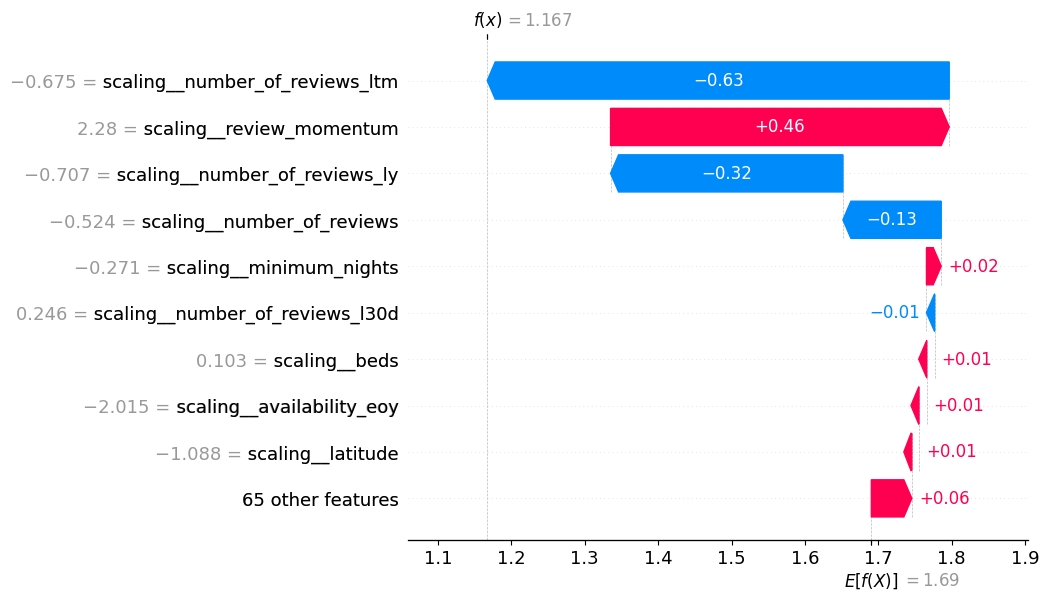

In [35]:
shap.plots.waterfall(train_shap_values[ex1_idx])

We randomly selected an example (the 25th) from the training set and generated a SHAP plot for it. The SHAP plot for this sample shows that the model started with a baseline prediction of 1.69 and ultimately produced a value of 1.167, whilst the true value was 1.28, resulting in a slight underestimation of approximately 0.11.

We found that features related to the number of reviews exerted the strongest negative influence on this sample. `number_of_reviews_ltm` contributed -0.63, `number_of_reviews_ly` approximately -0.32, and `number_of_reviews` approximately -0.13, collectively pushing the prediction significantly lower. In contrast, `review_momentum` provided the greatest positive compensation, at approximately +0.46. The contributions of other features, such as `minimum_nights`, `beds`, and `latitude`, were all very small. Overall, this demonstrates that the model is most sensitive to the features related to review.



<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

Our best model is the random forest model, which achieved an R² score of 0.8377 in previous validation.

In [36]:

pipe_rf.fit(X_train, y_train)

y_pred = pipe_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print(f"[Test] R2  : {r2:.4f}")
print(f"[Test] MAE : {mae:.4f}")
print(f"[Test] RMSE: {rmse:.4f}")

resid = y_test - y_pred
print(f"[Test] Residual mean: {np.mean(resid):.4f}")
print(f"[Test] Residual std : {np.std(resid):.4f}")


[Test] R2  : 0.7704
[Test] MAE : 0.6558
[Test] RMSE: 1.1058
[Test] Residual mean: 0.1796
[Test] Residual std : 1.0361


The evaluation results for the test set were R² = 0.7704, MAE = 0.6558, and RMSE = 1.1058. Previously, the training set score for the Random Forest model was R² = 0.8377. A comparison shows that the R² for the test set has decreased by approximately 0.06 compared to the validation/CV set, which shows that the validation phase appeared more promising and the model’s generalisation performance on truly unseen data did not reach the level observed during validation.

Although the test R² remains high and is significantly better than the Dummy baseline, the discrepancy with the validation results suggests that the results are not stable, and there may be little overfitting. This could be due to the Random Forest’s deep tree structure and small leaf nodes. And it could also be caused by differences in data distribution, meaning that the patterns learned during the validation phase are not fully applicable to the test data. We do believe the model can predict effectively, but we are not entirely confident, since we only have R² = 0.7704.

We believe there is a possibility of optimisation bias. We repeatedly compare models, tune hyperparameters, and select the best scores within the same data split. Furthermore, the range of our grid search during hyperparameter tuning is limited, and the differences in scores may simply represent a chance optimisation. Also, the fact that our actual test scores are lower than our training scores suggests the optimisation bias might exist.


In [37]:
X_test_enc = pd.DataFrame(
    data=preprocessor.transform(X_test),
    columns=feature_names,
    index=X_test.index,
)


In [38]:
model= pipe_rf.named_steps['randomforestregressor'] 
model.fit(X_test_enc, y_test)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [39]:
explainer = shap.TreeExplainer(model) # define the shap explainer 
test_shap_values = explainer(X_test_enc) # test shap values 
print(test_shap_values.shape)

(124, 74)


In [40]:
ex2_idx = 42
print("The exsample faetures:")
print(X_test_enc.iloc[ex2_idx])
print("Predict:", model.predict(X_test_enc)[ex2_idx])
print("actrual:", y_test.iloc[ex2_idx])

The exsample faetures:
scaling__accommodates                             -0.608428
scaling__bathrooms                                 0.432935
scaling__bedrooms                                 -0.527724
scaling__beds                                     -1.323006
scaling__host_listings_count                      -0.100587
                                                     ...   
onehot__property_type_Private room in townhouse    0.000000
onehot__property_type_Room in hotel                0.000000
onehot__room_type_Entire home/apt                  1.000000
onehot__room_type_Private room                     0.000000
onehot__has_availability_t                         1.000000
Name: 236, Length: 74, dtype: float64
Predict: 3.4684216648629143
actrual: 3.55


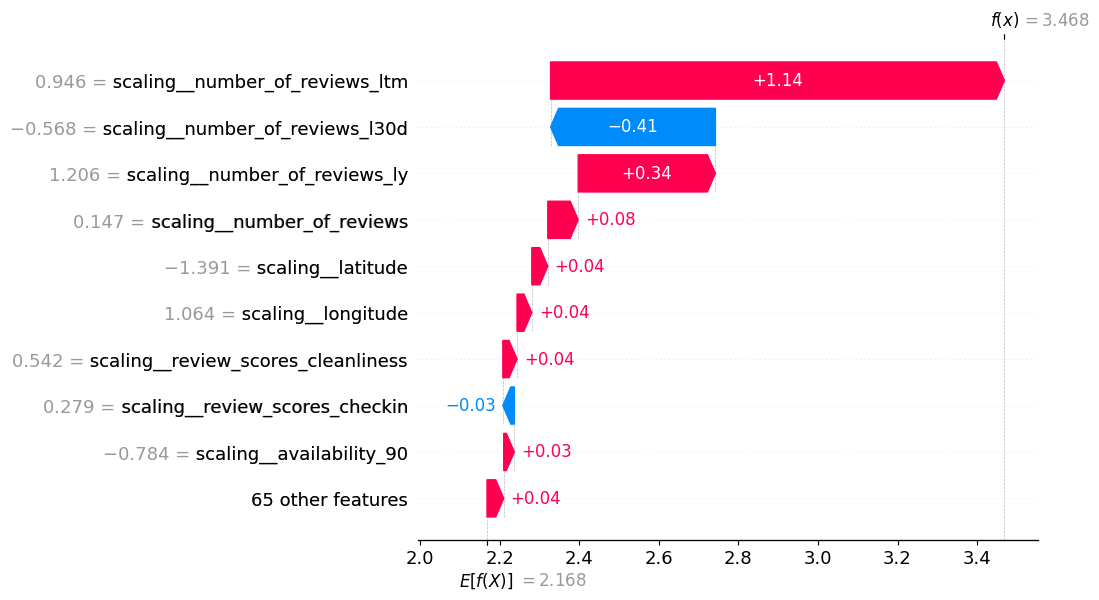

In [41]:
shap.plots.waterfall(test_shap_values[ex2_idx])

On this test set, the model predicted 3.468, whilst the true value was 3.55, resulting in an error of approximately -0.082. This represents a slight underestimation, but it is very close. Looking at the SHAP waterfall plot, the model starts from a baseline of 2.168 and is driven to 3.468 by key features. 

The largest positive contribution comes from `number_of_reviews_ltm`, at approximately +1.14, indicating that the model believes `number_of_reviews_ltm` significantly increases the target value. Meanwhile, `number_of_reviews_ly` also provides a positive contribution of approximately +0.34. Apart from this, `number_of_reviews` contributes only a slight positive effect of +0.08, indicating that the model emphasizes recent and annual activity rather than just historical cumulative figures.

The primary negative factor is number_of_reviews_l30d, at approximately -0.41, meaning that weaker recent short-term popularity in this sample will drag down the prediction. Furthermore, the contributions of geographical location (latitude, longitude), review_scores_cleanliness, review_scores_checkin, and availability_90 are all very small, ranging from ± 0.03 to 0.04. This indicates that the sensitivity of the rating of these features is relatively low for this sample. 

The final prediction is close to the actual value but slightly on the conservative side.



<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

This project primarily uses R² as the key metric, the higher the better, whilst also reporting MAE and RMSE, the lower the better.

To begin with, we used a linear model based on the Ridge and carried out basic parameter tuning and cross-validation. At this stage, we achieved results of MAE ≈ 0.49 with a standard deviation of 0.06 and a mean R² ≈ of 0.8204 with a standard deviation of 0.04.

We then added three further models, Random Forest, LightGBM, and Gradient Boosting, and compared them with the Ridge linear model. At this stage, we have found that Random Forest and GradientBoosting showed the best performance, both achieving a mean R² above 0.83 and the lowest MAE. Following the discussion, we decided to fine-tune the parameters of the Random Forest model and achieved an R² value of 0.8377. It is possible that the scope of our experiments was too narrow, which prevented us from achieving a significant improvement.

We then evaluated this fine-tuned Random Forest model using the final test set. We obtained scores of R² = 0.7704, MAE = 0.6558 and RMSE = 1.1058. There is a slight discrepancy compared to the scores we obtained on the training set, which may indicate a slight issue with overfitting.

During the process, we also analysed the significance of the features and their contribution to the model. We found that the features most closely related to the number of reviews and review activity tended to make the greatest contribution to predictions, and factors such as location, cleanliness, and guest experience had a relatively small impact on data points. Shows that in many cases, the model’s decisions are driven by a small number of key features.

Overall, our model has relatively good predictive ability

In the future, we may be able to employ a more systematic approach to hyperparameter optimisation and experiment with Randomised Search CV to improve search efficiency and identify better hyperparameters. In addition, we should attempt to fine-tune more models to achieve better results, such as the LightGBM model. Furthermore, for certain features, we could explore more feature engineering actions to get those with the greatest influence. This should improve our model.



We use R² as the final metric, alongside the error metrics MAE and RMSE.
- R² = 0.7704, 
- MAE = 0.6558 
- RMSE = 1.1058. 

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

Our key takeaway is that, in supervised learning, we do not always want to choose the most complex model, but to use the right methods to ensure the model is evaluated correctly. The scores of the same model can vary significantly across the training, validation, and test sets, so it is essential to use cross-validation and an independent test set to confirm that it can truly generalise.

Furthermore, data and features are often more critical than the model itself. Good features can make even a simple model very powerful. Therefore, feature engineering and preprocessing are really important; they directly determine the quality of our model.

Finally, interpretability methods such as SHAP help us understand which features the model primarily focuses on, allowing us to use the model with greater confidence and making it easier to improve.


<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please make sure you have followed all the instructions in the Instructions section at the top.

Here is a quick checklist before submitting:

- [ ] Restart the kernel and run all cells.
- [ ] `hw5.ipynb` runs without errors and contains all outputs.
- [ ] Save `hw5.ipynb` in JupyterLab.
- [ ] Return to the PrairieLearn question page and click **Save only** to check the rendered notebook preview.
- [ ] When the preview looks correct, click **Save & Grade**.
- [ ] If you are working in a group, confirm your PrairieLearn group membership is correct.
- [ ] Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2026S1/docs/homework-instructions/) for details on the grading process.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)